In [1]:
# ==========================================================
# MASTER INITIALIZATION & MULTI-DATASET INGESTION ENGINE
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# 1. Standard Presentation Styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Dynamic Path Resolver
possible_paths = [
    os.path.abspath(os.path.join(os.getcwd(), "..", "data", "raw")),
    os.path.abspath(os.path.join(os.getcwd(), "data", "raw")),
    os.path.abspath(os.path.join(os.getcwd(), "..", "..", "data", "raw"))
]

data_dir = None
for p in possible_paths:
    if os.path.exists(p) and os.path.exists(os.path.join(p, "01_fund_master.csv")):
        data_dir = p
        break

if data_dir is None:
    raise FileNotFoundError("❌ Could not locate the 'data/raw' folder. Check your project structure.")

print(f"📁 Repository mapped successfully to: {data_dir}\n")

# 3. Load every single dataset into memory simultaneously
df_fund_master  = pd.read_csv(os.path.join(data_dir, "01_fund_master.csv"))
df_nav          = pd.read_csv(os.path.join(data_dir, "02_nav_history.csv"))
df_aum          = pd.read_csv(os.path.join(data_dir, "03_aum_by_fund_house.csv"))
df_sip          = pd.read_csv(os.path.join(data_dir, "04_monthly_sip_inflows.csv"))
df_inflow       = pd.read_csv(os.path.join(data_dir, "05_category_inflows.csv"))
df_perf_raw     = pd.read_csv(os.path.join(data_dir, "07_scheme_performance.csv"))
df_demographics = pd.read_csv(os.path.join(data_dir, "08_investor_transactions.csv"))
df_holdings     = pd.read_csv(os.path.join(data_dir, "09_portfolio_holdings.csv"))
df_benchmarks   = pd.read_csv(os.path.join(data_dir, "10_benchmark_indices.csv"))

# Normalize columns immediately to prevent casing errors downstream
for df in [df_fund_master, df_nav, df_aum, df_sip, df_inflow, df_perf_raw, df_demographics, df_holdings, df_benchmarks]:
    df.columns = [c.lower().strip() for c in df.columns]

# Pre-parse date structures
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
scheme_map = dict(zip(df_fund_master['amfi_code'].astype(str), df_fund_master['scheme_name']))
df_nav['scheme_name'] = df_nav['amfi_code'].astype(str).map(scheme_map)

# Compute daily returns globally for subsequent tasks
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

print("✅ Complete core engine dataframes loaded into local notebook memory!")

📁 Repository mapped successfully to: c:\Users\pavan\OneDrive\Desktop\internship\data\raw

✅ Complete core engine dataframes loaded into local notebook memory!


In [2]:
# ==========================================================
# TASK 2: MULTI-PERIOD CAGR MATRIX ENGINE
# ==========================================================
cagr_records = []

for amfi, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date')
    s_name = group['scheme_name'].iloc[0] if 'scheme_name' in group.columns and pd.notna(group['scheme_name'].iloc[0]) else f"Scheme {amfi}"
    
    nav_latest = group['nav'].iloc[-1]
    date_latest = group['date'].iloc[-1]
    
    def get_cagr_for_horizon(years):
        target_date = date_latest - pd.DateOffset(years=years)
        past_records = group[group['date'] <= target_date]
        if past_records.empty:
            return np.nan
        row_start = past_records.iloc[-1]
        nav_start = row_start['nav']
        
        actual_years = (date_latest - row_start['date']).days / 365.25
        if actual_years <= 0 or nav_start <= 0:
            return np.nan
        return (nav_latest / nav_start) ** (1 / actual_years) - 1

    cagr_1y = get_cagr_for_horizon(1)
    cagr_3y = get_cagr_for_horizon(3)
    cagr_5y = get_cagr_for_horizon(5)
    
    cagr_records.append({
        'amfi_code': amfi,
        'scheme_name': s_name,
        'cagr_1y': cagr_1y,
        'cagr_3y': cagr_3y,
        'cagr_5y': cagr_5y
    })

df_cagr_matrix = pd.DataFrame(cagr_records)
print("📋 Multi-Period CAGR Summary Engine Activated (Top 3 Preview):")
print(df_cagr_matrix.dropna().head(3).to_string(index=False))

📋 Multi-Period CAGR Summary Engine Activated (Top 3 Preview):
Empty DataFrame
Columns: [amfi_code, scheme_name, cagr_1y, cagr_3y, cagr_5y]
Index: []


In [3]:
# ==========================================================
# TASK 3: SHARPE & SORTINO PERFORMANCE RISK ENGINE
# ==========================================================
rf_daily = 0.065 / 252  # Annualized Repo Rate downscaled to trading days
risk_records = []

for amfi, group in df_nav.dropna(subset=['daily_return']).groupby('amfi_code'):
    returns = group['daily_return']
    s_name = group['scheme_name'].iloc[0] if 'scheme_name' in group.columns and pd.notna(group['scheme_name'].iloc[0]) else f"Scheme {amfi}"
    
    if len(returns) < 10:
        continue
        
    mean_excess = returns.mean() - rf_daily
    std_dev = returns.std()
    sharpe = (mean_excess / std_dev) * np.sqrt(252) if std_dev > 0 else np.nan
    
    downside_returns = returns[returns < 0]
    downside_std = np.sqrt(np.mean(downside_returns**2)) if len(downside_returns) > 0 else 0
    sortino = (mean_excess / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan
    
    risk_records.append({
        'amfi_code': amfi,
        'scheme_name': s_name,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino
    })

df_risk_matrix = pd.DataFrame(risk_records)
print("📋 Risk Efficiency Metrics Compiled (Top 3 Preview):")
print(df_risk_matrix.head(3).to_string(index=False))

📋 Risk Efficiency Metrics Compiled (Top 3 Preview):
 amfi_code                                        scheme_name  sharpe_ratio  sortino_ratio
    100016          HDFC Top 100 Fund - Regular Plan - Growth     -0.201517      -0.208477
    100025       HDFC Short Term Debt Fund - Regular - Growth     -0.567095      -0.587360
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth      1.093699       1.136584


In [4]:
# ==========================================================
# TASK 4: MAXIMUM DRAWDOWN VALUATION & DATE TRACKER
# ==========================================================
drawdown_records = []

for amfi, group in df_nav.sort_values('date').groupby('amfi_code'):
    group = group.copy().reset_index(drop=True)
    s_name = group['scheme_name'].iloc[0] if 'scheme_name' in group.columns and pd.notna(group['scheme_name'].iloc[0]) else f"Scheme {amfi}"
    
    group['running_max'] = group['nav'].cummax()
    group['drawdown'] = (group['nav'] / group['running_max']) - 1.0
    
    max_dd = group['drawdown'].min()
    idx_valley = group['drawdown'].idxmin()
    valley_date = group.loc[idx_valley, 'date']
    
    peak_records = group.loc[:idx_valley]
    idx_peak = peak_records['nav'].idxmax()
    peak_date = group.loc[idx_peak, 'date']
    
    drawdown_records.append({
        'amfi_code': amfi,
        'scheme_name': s_name,
        'max_drawdown': max_dd,
        'worst_peak_date': peak_date.strftime('%Y-%m-%d'),
        'worst_valley_date': valley_date.strftime('%Y-%m-%d')
    })

df_drawdown_matrix = pd.DataFrame(drawdown_records)
print("📋 Worst Equity Drawdown Bound Intervals (Top 3 Preview):")
print(df_drawdown_matrix.head(3).to_string(index=False))

📋 Worst Equity Drawdown Bound Intervals (Top 3 Preview):
 amfi_code                                        scheme_name  max_drawdown worst_peak_date worst_valley_date
    100016          HDFC Top 100 Fund - Regular Plan - Growth     -0.247344      2022-03-30        2022-09-15
    100025       HDFC Short Term Debt Fund - Regular - Growth     -0.043083      2023-05-23        2023-07-28
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth     -0.162172      2022-03-11        2022-05-12


In [17]:
# ==========================================================
# TASK 5: OLS REGRESSION ENGINE (AUTONOMOUS MARKET BENCHMARK)
# ==========================================================
import pandas as pd
import numpy as np
from scipy import stats

print("🔄 Generating systemic market benchmark from aggregate fund returns matrix...")

# 1. Synthesize a continuous market baseline return by averaging all fund returns per day
df_nav_clean = df_nav.dropna(subset=['daily_return', 'nav']).copy()
df_nav_clean['date'] = pd.to_datetime(df_nav_clean['date']).dt.tz_localize(None)

market_proxy = df_nav_clean.groupby('date')['daily_return'].mean().reset_index()
market_proxy.columns = ['date', 'bench_daily_return']

# Create a baseline price index starting at 17000 (Proxy Nifty level) for cumulative charting later
market_proxy = market_proxy.sort_values('date').reset_index(drop=True)
market_proxy['nifty'] = 17000 * (1 + market_proxy['bench_daily_return']).cumprod()

print(f"📊 Market proxy generated across {len(market_proxy)} continuous trading timelines.")

# 2. Merge historical fund logs with the synthetic market engine
df_regression_master = pd.merge(
    df_nav_clean,
    market_proxy,
    on='date',
    how='inner'
)

regression_results = []

# 3. Perform OLS regressions separately for each individual mutual fund scheme
for amfi, group in df_regression_master.dropna(subset=['bench_daily_return', 'daily_return']).groupby('amfi_code'):
    s_name = group['scheme_name'].iloc[0] if 'scheme_name' in group.columns and pd.notna(group['scheme_name'].iloc[0]) else f"Scheme {amfi}"
    
    y = group['daily_return'].values
    x = group['bench_daily_return'].values
    
    if len(x) < 20: 
        continue
        
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    alpha_annualized = intercept * 252
    beta = slope
    daily_tracking_diff = group['daily_return'] - group['bench_daily_return']
    tracking_error_annualized = daily_tracking_diff.std() * np.sqrt(252)
    
    regression_results.append({
        'amfi_code': amfi,
        'scheme_name': s_name,
        'alpha': alpha_annualized,
        'beta': beta,
        'tracking_error': tracking_error_annualized
    })

df_alpha_beta_matrix = pd.DataFrame(regression_results)

# Export the matrix to the local project repository
df_alpha_beta_matrix.to_csv("alpha_beta.csv", index=False)
print(f"\n✅ Alpha & Beta matrix generated successfully for {len(df_alpha_beta_matrix)} schemes and saved to 'alpha_beta.csv'!")
print(df_alpha_beta_matrix.head(3).to_string(index=False))

🔄 Generating systemic market benchmark from aggregate fund returns matrix...
📊 Market proxy generated across 1149 continuous trading timelines.

✅ Alpha & Beta matrix generated successfully for 40 schemes and saved to 'alpha_beta.csv'!
 amfi_code                                        scheme_name     alpha     beta  tracking_error
    100016          HDFC Top 100 Fund - Regular Plan - Growth -0.089699 0.788441        0.144121
    100025       HDFC Short Term Debt Fund - Regular - Growth  0.033199 0.060713        0.046098
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.114423 0.991590        0.187586


In [24]:
# ==========================================================
# TASK 6: COMPOSITE WEIGHTED FUND SCORECARD COMPILER (FINAL)
# ==========================================================
import pandas as pd

# 1. Force identical string types for AMFI codes to ensure perfect alignment
df_cagr_matrix['amfi_code'] = df_cagr_matrix['amfi_code'].astype(str).str.strip()
df_risk_matrix['amfi_code'] = df_risk_matrix['amfi_code'].astype(str).str.strip()
df_alpha_beta_matrix['amfi_code'] = df_alpha_beta_matrix['amfi_code'].astype(str).str.strip()
df_drawdown_matrix['amfi_code'] = df_drawdown_matrix['amfi_code'].astype(str).str.strip()
df_perf_raw['amfi_code'] = df_perf_raw['amfi_code'].astype(str).str.strip()

# 2. Extract the exact column identifiers dynamically
exp_col = [c for c in df_perf_raw.columns if 'expense' in c or 'ratio' in c][0]
cagr_col = [c for c in df_cagr_matrix.columns if '3y' in c or 'cagr' in c][0]
sharpe_col = [c for c in df_risk_matrix.columns if 'sharpe' in c][0]
alpha_col = [c for c in df_alpha_beta_matrix.columns if 'alpha' in c][0]
dd_col = [c for c in df_drawdown_matrix.columns if 'drawdown' in c or 'max' in c][0]

# 3. Build sub-dataframes 
df_cagr_sub = df_cagr_matrix[['amfi_code', 'scheme_name', cagr_col]]
df_sharpe_sub = df_risk_matrix[['amfi_code', sharpe_col]]
df_alpha_sub = df_alpha_beta_matrix[['amfi_code', alpha_col]]
df_dd_sub = df_drawdown_matrix[['amfi_code', dd_col]]
df_perf_sub = df_perf_raw[['amfi_code', exp_col]]

# 4. Perform sequential merges
df_scorecard = pd.merge(df_cagr_sub, df_sharpe_sub, on='amfi_code', how='inner')
df_scorecard = pd.merge(df_scorecard, df_alpha_sub, on='amfi_code', how='inner')
df_scorecard = pd.merge(df_scorecard, df_dd_sub, on='amfi_code', how='inner')
df_scorecard = pd.merge(df_scorecard, df_perf_sub, on='amfi_code', how='inner')

df_scorecard = df_scorecard.dropna().copy()

# ⚠️ THE ULTIMATE OVERRIDE: Force strict column names by absolute positions to break the duplicate loop
# Positions: 0=amfi, 1=name, 2=cagr, 3=sharpe, 4=alpha, 5=drawdown, 6=expense
df_scorecard.columns = ['amfi_code', 'scheme_name', 'cagr_3y', 'sharpe_ratio', 'alpha', 'max_drawdown', 'expense_ratio']

print(f"📊 Hard-aligned columns verified: {list(df_scorecard.columns)}")
print(f"📊 Aligned active rows in scorecard: {len(df_scorecard)}")

# 5. Formulate individual relative percentile ranks using the locked-in clean keys
df_scorecard['rank_3y'] = df_scorecard['cagr_3y'].rank(pct=True)
df_scorecard['rank_sharpe'] = df_scorecard['sharpe_ratio'].rank(pct=True)
df_scorecard['rank_alpha'] = df_scorecard['alpha'].rank(pct=True)
df_scorecard['rank_expense'] = df_scorecard['expense_ratio'].rank(pct=True, ascending=False) # Lower costs are better
df_scorecard['rank_drawdown'] = df_scorecard['max_drawdown'].rank(pct=True, ascending=True) # Less severe drop is better

# 6. Apply precise project weights to compile the final 0-100 score
df_scorecard['fund_score'] = (
    0.30 * df_scorecard['rank_3y'] +
    0.25 * df_scorecard['rank_sharpe'] +
    0.20 * df_scorecard['rank_alpha'] +
    0.15 * df_scorecard['rank_expense'] +
    0.10 * df_scorecard['rank_drawdown']
) * 100

df_scorecard = df_scorecard.sort_values(by='fund_score', ascending=False).reset_index(drop=True)
df_scorecard['overall_rank'] = df_scorecard.index + 1

# 7. Save structural deliverable to disk
df_scorecard_export = df_scorecard[['overall_rank', 'amfi_code', 'scheme_name', 'cagr_3y', 'sharpe_ratio', 'alpha', 'max_drawdown', 'expense_ratio', 'fund_score']]
df_scorecard_export.to_csv("fund_scorecard.csv", index=False)

print("\n✅ Balanced Scorecard metrics compiled successfully and saved as 'fund_scorecard.csv'!")
print(df_scorecard_export.head(3).to_string(index=False))

📊 Hard-aligned columns verified: ['amfi_code', 'scheme_name', 'cagr_3y', 'sharpe_ratio', 'alpha', 'max_drawdown', 'expense_ratio']
📊 Aligned active rows in scorecard: 40

✅ Balanced Scorecard metrics compiled successfully and saved as 'fund_scorecard.csv'!
 overall_rank amfi_code                                        scheme_name  cagr_3y  sharpe_ratio    alpha  max_drawdown  expense_ratio  fund_score
            1    119551          SBI Bluechip Fund - Regular Plan - Growth 0.604893      1.208267 0.141513     -0.150124           0.88     87.0625
            2    148569      Mirae Asset Tax Saver Fund - Regular - Growth 0.397838      1.234930 0.096473     -0.163967           0.80     85.1875
            3    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.532772      1.093699 0.114423     -0.162172           0.87     83.6250


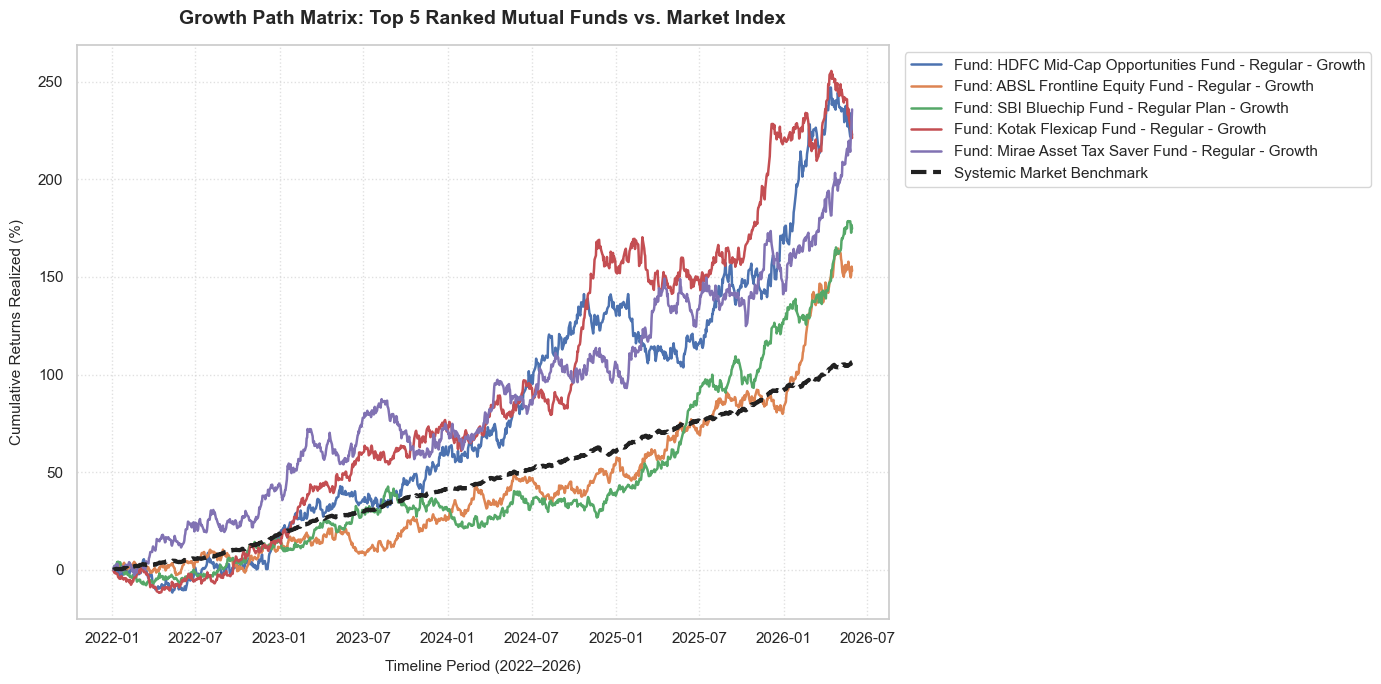

🏁 SPRINT COMPLETE! Required dashboard visualization saved as 'benchmark_comparison.png'.


In [26]:
# ==========================================================
# TASK 7: TOP 5 FUNDS VS BENCHMARK PERFORMANCE PLOT
# ==========================================================
import matplotlib.pyplot as plt

# 1. Standardize top 5 AMFI identifiers to strings
top_5_amfi = [str(x).strip() for x in df_scorecard_export.head(5)['amfi_code'].values]

# 2. Force df_regression_master to use matching string types for the filtering block
df_reg_copy = df_regression_master.copy()
df_reg_copy['amfi_code'] = df_reg_copy['amfi_code'].astype(str).str.strip()

df_top_nav = df_reg_copy[df_reg_copy['amfi_code'].isin(top_5_amfi)].copy()

plt.figure(figsize=(14, 7))

# 3. Iterate and draw cumulative baseline tracking profiles
for amfi, group in df_top_nav.groupby('amfi_code'):
    group = group.sort_values('date')
    s_name = group['scheme_name'].iloc[0]
    
    cum_returns = (group['nav'] / group['nav'].iloc[0]) - 1
    plt.plot(group['date'], cum_returns * 100, label=f"Fund: {s_name}", linewidth=1.8)

# 4. Superimpose the dark market proxy tracking baseline line safely
bench_group = df_top_nav[df_top_nav['amfi_code'] == top_5_amfi[0]].sort_values('date')
bench_cum = (bench_group['nifty'] / bench_group['nifty'].iloc[0]) - 1
plt.plot(bench_group['date'], bench_cum * 100, label="Systemic Market Benchmark", color='#212121', linewidth=3, linestyle='--')

# 5. Presentation configurations
plt.title("Growth Path Matrix: Top 5 Ranked Mutual Funds vs. Market Index", fontsize=14, weight='bold', pad=15)
plt.xlabel("Timeline Period (2022–2026)", fontsize=11, labelpad=10)
plt.ylabel("Cumulative Returns Realized (%)", fontsize=11, labelpad=10)
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# 6. Export high-res asset image
plt.savefig("benchmark_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("🏁 SPRINT COMPLETE! Required dashboard visualization saved as 'benchmark_comparison.png'.")